# Taller 01 · Parte 2 — Decodificación: exposición de parámetros y barrido



## 2.a — Verificar la matriz de exposición
La tabla semestral trae un campo parametros_expuestos, pero ese campo sale de la **documentación**, no de una llamada. Que un parámetro exista en la documentación no significa que el modelo que llamamos lo obedezca. Cada celda (modelo × parámetro) termina en uno de tres estados:

| Estado | Cómo se comprueba aquí |
|---|---|
| **Aceptado y actúa** | la API responde 200 y dos valores extremos del parámetro producen salidas con dispersión claramente distinta en 8 corridas |
| **Aceptado y no actúa** | responde 200 pero la dispersión no cambia entre valores extremos |
| **Rechazado** | devuelve error; se transcribe el código y el mensaje **literal**, con la fecha |

Un cuarto caso aparece en la tabla como solo_valor_por_defecto: acepta el valor por defecto y rechaza cualquier otro.

**Regla para decir «actúa» (fijada antes de mirar los datos).** Prompt abierto, Name a random animal. Reply with one word only., 8 corridas por condición, y se cuentan las **respuestas distintas** (normalizadas a minúsculas y sin puntuación). Una condición «caliente» (temperature = 1.6) es la referencia:

- temperature actúa si distintas(1.6) − distintas(0) ≥ 3.
- top_p actúa si distintas(1.6, top_p = 1.0) − distintas(1.6, top_p = 0.01) ≥ 3 (a T = 1.6 la distribución es plana; con un valor tan bajo el núcleo se reduce al token más probable).
- top_k actúa si distintas(1.6, top_k = 100) − distintas(1.6, top_k = 1) ≥ 3.
- Si la referencia caliente tiene menos de 4 respuestas distintas, la prueba **no tiene poder** y se reporta como «no concluyente» en lugar de «no actúa».



## 0. Preparación
Constantes, los regímenes que probamos en cada modelo y las condiciones de cada dial. Un **régimen** es una forma de llamar al modelo: para gpt-5.6-luna probamos dos, con el esfuerzo de razonamiento por defecto (medium) y con effort = none, porque un modelo puede rechazar el muestreo en un régimen y aceptarlo en otro.

In [ ]:
import re, collections
import numpy as np
import pandas as pd

from taller_01_miguel_alvarez import tallerlib as tl

print("Variables leídas de .env (solo nombres):", tl.cargar_env())
print("OPENAI_API_KEY utilizable:", tl.hay_clave("OPENAI_API_KEY"))
tl.DIR_RESULTADOS.mkdir(exist_ok=True)

RELANZAR_LLAMADAS = False   # False: si ya hay filas de la parte 2a se reutilizan. True: borra la parte 2a y vuelve a llamar
PARTE = "2a"
PROMPT_2A = "Name a random animal. Reply with one word only."
N_CORRIDAS = 8
T_ALTA = 1.6
TOP_P_BAJO = 0.01   # valor extremo: a T=1.6 la distribución es plana y con 0.1 el núcleo aún cabría varios animales
UMBRAL = 3
MODELOS_2A = ["propietario_economico", "openai_razonamiento", "open_weight_pequeno"]
DIALES = ["temperature", "top_p", "top_k"]

LOCAL_BASE = {"think": False, "num_predict": 20}
REGIMENES = {   # modelo -> {régimen: parámetros fijos de ese régimen}
    "propietario_economico": {"defecto": {"max_output_tokens": 30}},
    "openai_razonamiento": {"effort=medium(defecto)": {"max_output_tokens": 2000},
                            "effort=none": {"max_output_tokens": 2000, "effort": "none"}},
    "open_weight_pequeno": {"think=False": LOCAL_BASE},
}
# Sondas de una llamada para las filas de OpenAI: (dial, valor, parámetros extra)
SONDAS_OPENAI = [
    ("temperature", 1.6, {"temperature": 1.6}),
    ("temperature", 1.0, {"temperature": 1.0}),                # 1.0 = valor por defecto
    ("top_p", TOP_P_BAJO, {"top_p": TOP_P_BAJO}),
    ("top_p", 1.0, {"top_p": 1.0}),                            # 1.0 = valor por defecto
    ("top_k", 40, {"extra_body": {"top_k": 40}}),              # el SDK no lo conoce: va por extra_body
]
# Condiciones de medición para el modelo local. Se fijan top_p y top_k de forma explícita porque
# los valores por defecto de Ollama (top_p = 0.9, top_k = 40) ya recortan la distribución.
LOCAL_CONDICIONES = {
    "T0": {"temperature": 0, "top_p": 1.0, "top_k": 100},
    "BASE": {"temperature": T_ALTA, "top_p": 1.0, "top_k": 100},
    "TOPP_BAJO": {"temperature": T_ALTA, "top_p": TOP_P_BAJO, "top_k": 100},
    "TOPK1": {"temperature": T_ALTA, "top_p": 1.0, "top_k": 1},
    # control: clave mal escrita en lugar de temperature (Ollama la acepta con 200 y no hace nada)
    "CTRL_typo": {"top_p": 1.0, "top_k": 100, "options_extra": {"temparature": 0.0}},
}


def normalizar(s):
    return re.sub(r"[^a-záéíóúñü ]", "", (s or "").strip().lower()).strip()


def filas_2a():
    return [f for f in tl.leer_filas() if f["parte"] == PARTE]


def partir(f):
    reg, tipo, detalle = f["variante"].split("|", 2)
    return reg, tipo, detalle

Variables leídas de .env (solo nombres): []
OPENAI_API_KEY utilizable: True


## 1. Lo que declara la tabla
Esto es lo que vamos a comprobar. Sale de parametros_expuestos (documentación oficial, no una llamada).

In [2]:
declarado = {(mid, d): tl.fila_modelo(mid)["parametros_expuestos"][d] for mid in MODELOS_2A for d in DIALES}
print(pd.DataFrame([{"modelo": mid, **{d: declarado[(mid, d)] for d in DIALES}} for mid in MODELOS_2A]).to_string(index=False))
print()
for mid in MODELOS_2A:
    print(f"{mid:<24} precios verificados el: {tl.fila_modelo(mid)['verificado'] or '-'}")

               modelo     temperature           top_p top_k
propietario_economico              si              si    no
  openai_razonamiento no_en_esta_fila no_en_esta_fila    no
  open_weight_pequeno              si              si    si

propietario_economico    precios verificados el: 2026-08-26
openai_razonamiento      precios verificados el: 2026-09-18
open_weight_pequeno      precios verificados el: -


## 2. Estimación de costo antes de lanzar
Cota superior con los supuestos declarados. Usamos lo que aprendimos en la Parte 1: la fila de razonamiento gastó unos 35 tokens de salida por llamada (no miles), así que ese es el supuesto de ahora; si esta vez difiere, es otro hallazgo.

In [3]:
n_sondas_oa = len(SONDAS_OPENAI)
n_meds_gpt4o = 3 * N_CORRIDAS                                    # T0, BASE, TOPP_BAJO
n_meds_luna = 2 * 3 * N_CORRIDAS                                 # peor caso: dos regímenes aceptan
tok_in = round(len(PROMPT_2A) / 4)
est = {
    "propietario_economico": (n_sondas_oa + n_meds_gpt4o, 30),
    "openai_razonamiento": (2 * n_sondas_oa + n_meds_luna, 35),
    "open_weight_pequeno": (1 + 6 * N_CORRIDAS, 20),   # sonda de rango + 5 condiciones + control top_kk
}
filas_est = []
for mid, (n, tout) in est.items():
    filas_est.append({"id": mid, "llamadas_max": n, "USD_max": round(tl.costo_usd(mid, tok_in * n, tout * n), 6)})
est_df = pd.DataFrame(filas_est)
print(est_df.to_string(index=False))
print(f"\nCota superior de la parte 2.a: {est_df.USD_max.sum():.4f} USD (presupuesto orientativo del taller: 0.04 USD)")

                   id  llamadas_max  USD_max
propietario_economico            29 0.000574
  openai_razonamiento            58 0.002575
  open_weight_pequeno            49 0.000000

Cota superior de la parte 2.a: 0.0031 USD (presupuesto orientativo del taller: 0.04 USD)


## 3. Fase 1 — sondas de una llamada
Una llamada por (régimen, dial, valor) en las dos filas de OpenAI, más una sonda de rango en Ollama (temperature = -5). Sirven para saber **qué acepta el servicio** antes de gastar las 8 corridas de la fase 2. Se guarda el mensaje de error literal.

In [4]:
hay_sondas = any(partir(f)[1] == "sonda" for f in filas_2a())
if RELANZAR_LLAMADAS or not hay_sondas:
    tl.reemplazar_partes({PARTE})
    tareas = []
    for mid in ["propietario_economico", "openai_razonamiento"]:
        for reg, base in REGIMENES[mid].items():
            for dial, valor, extra in SONDAS_OPENAI:
                tareas.append(dict(modelo_id=mid, prompt=PROMPT_2A, params={**base, **extra}, parte=PARTE,
                                   caso=dial, variante=f"{reg}|sonda|{valor}", corrida=0))
    tareas.append(dict(modelo_id="open_weight_pequeno", prompt=PROMPT_2A, params={**LOCAL_BASE, "temperature": -5},
                       parte=PARTE, caso="control", variante="think=False|sonda|temperature=-5", corrida=0))
    tl.correr_lote(tareas, hilos=1, max_usd=0.05)
else:
    print("Ya hay sondas registradas: se reutilizan (RELANZAR_LLAMADAS = True para repetirlas).")

sondas = pd.DataFrame([{"modelo_id": f["modelo_id"], "régimen": partir(f)[0], "dial=valor": f"{f['caso']}={partir(f)[2]}",
                        "resultado": "aceptada (200)" if not f["error"] else "RECHAZADA",
                        "fecha_utc": f["fecha_utc"][:19], "salida": f["salida"].strip()[:20],
                        "error_literal": f["error"]} for f in filas_2a() if partir(f)[1] == "sonda"])
print(sondas.drop(columns=["error_literal"]).to_string(index=False))
print("\nMensajes de error literales (únicos):")
for mid, reg, dv, e in sondas[sondas.error_literal != ""][["modelo_id", "régimen", "dial=valor", "error_literal"]].itertuples(index=False):
    print(f"- {mid} | {reg} | {dv}\n    {e}")

Ya hay sondas registradas: se reutilizan (RELANZAR_LLAMADAS = True para repetirlas).
            modelo_id                régimen             dial=valor      resultado           fecha_utc   salida
propietario_economico                defecto        temperature=1.6 aceptada (200) 2026-09-19T16:16:51  Quokka.
propietario_economico                defecto        temperature=1.0 aceptada (200) 2026-09-19T16:16:52 Penguin.
propietario_economico                defecto             top_p=0.01 aceptada (200) 2026-09-19T16:16:52 Octopus.
propietario_economico                defecto              top_p=1.0 aceptada (200) 2026-09-19T16:16:53 Giraffe.
propietario_economico                defecto               top_k=40      RECHAZADA 2026-09-19T16:16:54         
  openai_razonamiento effort=medium(defecto)        temperature=1.6      RECHAZADA 2026-09-19T16:16:54         
  openai_razonamiento effort=medium(defecto)        temperature=1.0 aceptada (200) 2026-09-19T16:16:56   Quokka
  openai_razonamien

## 4. Fase 2 — mediciones de «¿actúa?»
Solo se miden los diales que la fase 1 mostró aceptados. Cada condición se corre 8 veces. Las filas de OpenAI van en paralelo (aquí no medimos latencia); las locales, una a una.

In [5]:
def aceptada(mid, reg, dial, valor):
    for f in filas_2a():
        if f["modelo_id"] == mid and f["caso"] == dial and f["variante"] == f"{reg}|sonda|{valor}":
            return f["error"] == ""
    return False


def condiciones_openai(mid, reg, base):
    t_ok, p_ok, k_ok = aceptada(mid, reg, "temperature", T_ALTA), aceptada(mid, reg, "top_p", TOP_P_BAJO), aceptada(mid, reg, "top_k", 40)
    fondo = {"temperature": T_ALTA} if t_ok else {}
    c = {}
    if t_ok:
        c["T0"] = {"temperature": 0}
    if t_ok or p_ok or k_ok:
        c["BASE"] = dict(fondo)
    if p_ok:
        c["TOPP_BAJO"] = {**fondo, "top_p": TOP_P_BAJO}
    if k_ok:
        c["TOPK1"] = {**fondo, "extra_body": {"top_k": 1}}
    return {k: {**base, **v} for k, v in c.items()}


hay_med = any(partir(f)[1] == "med" for f in filas_2a())
if RELANZAR_LLAMADAS or not hay_med:
    t_openai, t_local = [], []
    for mid in ["propietario_economico", "openai_razonamiento"]:
        for reg, base in REGIMENES[mid].items():
            for cond, params in condiciones_openai(mid, reg, base).items():
                for i in range(N_CORRIDAS):
                    t_openai.append(dict(modelo_id=mid, prompt=PROMPT_2A, params=params, parte=PARTE,
                                         caso="medicion", variante=f"{reg}|med|{cond}", corrida=i))
    for cond, params in LOCAL_CONDICIONES.items():
        for i in range(N_CORRIDAS):
            t_local.append(dict(modelo_id="open_weight_pequeno", prompt=PROMPT_2A, params={**LOCAL_BASE, **params}, parte=PARTE,
                                caso="medicion", variante=f"think=False|med|{cond}", corrida=i))
    print(f"OpenAI: {len(t_openai)} llamadas | local: {len(t_local)} llamadas")
    tl.correr_lote(t_openai, hilos=4, max_usd=0.05, mostrar=False)
    tl.correr_lote(t_local, hilos=1, max_usd=0.05, mostrar=False)
else:
    print("Ya hay mediciones registradas: se reutilizan (RELANZAR_LLAMADAS = True para repetirlas).")

f2 = filas_2a()
print(f"Filas de la parte 2a: {len(f2)} | con error: {sum(1 for f in f2 if f['error'])} | costo total: {sum(float(f['costo_usd'] or 0) for f in f2):.6f} USD")

Ya hay mediciones registradas: se reutilizan (RELANZAR_LLAMADAS = True para repetirlas).
Filas de la parte 2a: 112 | con error: 6 | costo total: 0.000465 USD


## 5. Dispersión por condición
Para cada condición: cuántas corridas salieron bien, cuántas **respuestas distintas** dieron y cuáles fueron. Este es el dato crudo detrás de cada veredicto.

In [6]:
med = pd.DataFrame([{**f, "reg": partir(f)[0], "cond": partir(f)[2], "resp": normalizar(f["salida"])}
                    for f in filas_2a() if partir(f)[1] == "med"])
med_ok = med[med.error == ""]
dispersion = (med.groupby(["modelo_id", "reg", "cond"])
              .agg(corridas=("corrida", "size"), con_error=("error", lambda s: int((s != "").sum())))
              .join(med_ok.groupby(["modelo_id", "reg", "cond"]).resp.agg(distintas="nunique",
                    respuestas=lambda s: ", ".join(f"{k}×{v}" if v > 1 else k for k, v in collections.Counter(s).most_common())))
              .reset_index())
dispersion.to_csv(tl.DIR_RESULTADOS / "p2a_dispersion.csv", index=False)
pd.set_option("display.max_colwidth", 90)
print(dispersion.to_string(index=False))

            modelo_id         reg      cond  corridas  con_error  distintas                                                      respuestas
  open_weight_pequeno think=False      BASE         8          0          8          eagle, fox, sloth, cow, bird, zebra, crocodile, turtle
  open_weight_pequeno think=False CTRL_typo         8          0          1                                                         tiger×8
  open_weight_pequeno think=False        T0         8          0          1                                                         tiger×8
  open_weight_pequeno think=False     TOPK1         8          0          1                                                         tiger×8
  open_weight_pequeno think=False TOPP_BAJO         8          0          1                                                         tiger×8
  openai_razonamiento effort=none      BASE         8          0          5                  capybara×3, axolotl×2, penguin, wombat, quokka
  openai_razonamient

## 6. Matriz de exposición (entregable de 2.a)
Una fila por modelo × parámetro: lo que **declara** la tabla, lo que **observamos** (por régimen), la evidencia, la **fecha de la prueba (UTC)** y el **mensaje de error literal** en cada celda rechazada. La columna coincide compara declarado contra observado; toda discrepancia es un hallazgo.

In [7]:
def distintas(mid, reg, cond):
    d = dispersion[(dispersion.modelo_id == mid) & (dispersion.reg == reg) & (dispersion.cond == cond)]
    if d.empty or d.corridas.iloc[0] - d.con_error.iloc[0] == 0:
        return None
    return int(d.distintas.iloc[0])


PARES = {"temperature": ("T0", "BASE"), "top_p": ("TOPP_BAJO", "BASE"), "top_k": ("TOPK1", "BASE")}   # (baja, alta)


def clasificar(mid, reg, dial):
    """Devuelve (estado, evidencia, error_literal, fecha)."""
    rows = [f for f in filas_2a() if f["modelo_id"] == mid and partir(f)[0] == reg]
    sondas_d = [f for f in rows if partir(f)[1] == "sonda" and f["caso"] == dial]
    meds = [f for f in rows if partir(f)[1] == "med" and partir(f)[2] in PARES[dial]]
    fechas = [f["fecha_utc"][:10] for f in sondas_d + meds]
    fecha = min(fechas) if fechas else ""
    malos = [f for f in sondas_d if f["error"]]
    buenos = [f for f in sondas_d if not f["error"]]
    err = "; ".join(dict.fromkeys(f["error"] for f in malos))
    if sondas_d and malos and not buenos:
        return "rechazado", "todas las sondas devolvieron error: " + ", ".join(partir(f)[2] for f in malos), err, fecha
    if sondas_d and malos and buenos:
        return ("solo_valor_por_defecto",
                f"acepta {[partir(f)[2] for f in buenos]} y rechaza {[partir(f)[2] for f in malos]}", err, fecha)
    # aceptado: ¿actúa?
    baja, alta = PARES[dial]
    d_baja, d_alta = distintas(mid, reg, baja), distintas(mid, reg, alta)
    if d_baja is None or d_alta is None:
        errs_med = "; ".join(dict.fromkeys(f["error"] for f in meds if f["error"]))
        if errs_med:
            return "rechazado", "la medición devolvió error", errs_med, fecha
        return "aceptado (sin medir)", "faltan corridas para decidir", "", fecha
    ev = f"distintas: {baja}={d_baja}, {alta}={d_alta} (de {N_CORRIDAS})"
    if d_alta < UMBRAL + 1:
        return "no concluyente", ev + " → la referencia caliente ya es poco diversa", "", fecha
    return ("aceptado y actúa" if d_alta - d_baja >= UMBRAL else "aceptado y no actúa"), ev, "", fecha


ESPERADO = {"si": "aceptado y actúa", "no": "rechazado", "no_en_esta_fila": "rechazado",
            "solo_valor_por_defecto": "solo_valor_por_defecto"}
matriz = []
for mid in MODELOS_2A:
    for dial in DIALES:
        obs = {reg: clasificar(mid, reg, dial) for reg in REGIMENES[mid]}
        decl = declarado[(mid, dial)]
        esp = ESPERADO.get(decl)
        if esp is None:
            coincide = "no comparable (sin_verificar)"
        else:
            coincide = "sí" if all(o[0] == esp for o in obs.values()) else "NO — discrepancia"
        matriz.append({
            "modelo": tl.fila_modelo(mid)["modelo"], "parámetro": dial, "declara_la_tabla": decl,
            "observado": " | ".join(f"{reg}: {o[0]}" if len(obs) > 1 else o[0] for reg, o in obs.items()),
            "evidencia": " | ".join(f"[{reg}] {o[1]}" if len(obs) > 1 else o[1] for reg, o in obs.items()),
            "fecha_prueba_utc": min(o[3] for o in obs.values() if o[3]) if any(o[3] for o in obs.values()) else "",
            "coincide": coincide,
            "error_literal": " || ".join(f"[{reg}] {o[2]}" for reg, o in obs.items() if o[2]),
        })
matriz = pd.DataFrame(matriz)
matriz.to_csv(tl.DIR_RESULTADOS / "p2a_matriz.csv", index=False)
print(matriz.drop(columns=["error_literal", "evidencia"]).to_string(index=False))
print("\nEvidencia por celda:")
for r in matriz.itertuples():
    print(f"- {r.modelo:<14} {r.parámetro:<12} {r.evidencia}")
print("\nMensajes de error literales por celda rechazada:")
for r in matriz[matriz.error_literal != ""].itertuples():
    print(f"- {r.modelo} · {r.parámetro} ({r.fecha_prueba_utc}):\n    {r.error_literal}")

      modelo   parámetro declara_la_tabla                                                                      observado fecha_prueba_utc          coincide
 gpt-4o-mini temperature               si                                                               aceptado y actúa       2026-09-19                sí
 gpt-4o-mini       top_p               si                                                               aceptado y actúa       2026-09-19                sí
 gpt-4o-mini       top_k               no                                                                      rechazado       2026-09-19                sí
gpt-5.6-luna temperature  no_en_esta_fila effort=medium(defecto): solo_valor_por_defecto | effort=none: aceptado y actúa       2026-09-19 NO — discrepancia
gpt-5.6-luna       top_p  no_en_esta_fila              effort=medium(defecto): rechazado | effort=none: aceptado y actúa       2026-09-19 NO — discrepancia
gpt-5.6-luna       top_k               no                     ef

## 7. Controles de Ollama: un 200 no prueba que el parámetro exista
Un HTTP 200 no dice que el parámetro exista ni que haga algo. Ollama, además, no valida claves ni rangos. Tres comprobaciones:

1. **Qué valores trae el modelo por defecto.** Cuando no mandamos un dial, el modelo usa los suyos (los del *Modelfile*), no los de la teoría. Lo consultamos con /api/show.
2. **Valor absurdo:** temperature = -5.
3. **Clave inventada.** Aquí hay dos versiones y solo una discrimina:
   - *temparature en lugar de temperature* (CTRL_typo, la sección 4): equivale a **no mandar temperatura**, así que el modelo usa la suya por defecto. Si esa ya es casi determinista para este prompt, la salida colapsa igual que con temperature = 0 y el control **no puede distinguir** «la clave inventada no hizo nada» de «el valor por defecto ya es bajo». Es un hallazgo, no un control válido.
   - *top_kk = 1 junto a temperature = 1.6 bien escrita* (CTRL_top_kk, se corre abajo): si Ollama ignora la clave inventada, la salida sigue tan dispersa como la condición caliente; si la obedeciera, colapsaría como top_k = 1. Este sí discrimina.

In [8]:
import os, requests

host = os.environ.get("OLLAMA_HOST", "http://localhost:11434")
if not host.startswith("http"):
    host = "http://" + host
nombre_local = tl.fila_modelo("open_weight_pequeno")["modelo"]
try:
    r = requests.post(f"{host}/api/show", json={"model": nombre_local, "name": nombre_local}, timeout=30)
    r.raise_for_status()
    params_defecto = r.json().get("parameters") or "(el modelo no declara parámetros: valen los valores por defecto de Ollama)"
except Exception as e:
    params_defecto = "No se pudo consultar /api/show: " + tl._limpiar_secretos(str(e))
print(f"Parámetros por defecto de {nombre_local} en Ollama (lo que se usa cuando NO mandamos el dial):")
print(params_defecto)
(tl.DIR_RESULTADOS / "p2a_ollama_defaults.txt").write_text(f"{nombre_local}\n{params_defecto}\n", encoding="utf-8")

Parámetros por defecto de qwen3:1.7b en Ollama (lo que se usa cuando NO mandamos el dial):
repeat_penalty                 1
stop                           "<|im_start|>"
stop                           "<|im_end|>"
temperature                    0.6
top_k                          20
top_p                          0.95


239

In [9]:
rango = [f for f in filas_2a() if partir(f)[1] == "sonda" and f["modelo_id"] == "open_weight_pequeno"]
for f in rango:
    print(f"temperature = -5 → {'HTTP 200 (aceptada, sin validar el rango)' if not f['error'] else 'RECHAZADA: ' + f['error']} | salida: {f['salida'].strip()[:30]!r}")

d_t0 = distintas("open_weight_pequeno", "think=False", "T0")
d_typo = distintas("open_weight_pequeno", "think=False", "CTRL_typo")
print(f"\nControl 'temparature' (equivale a NO mandar temperatura): {d_typo} respuestas distintas de {N_CORRIDAS}; con temperature=0 bien escrita: {d_t0}.")
if None not in (d_t0, d_typo):
    if d_typo - d_t0 < UMBRAL:
        print("→ Colapsa igual que temperature=0: el valor por defecto del modelo ya es casi determinista para este prompt,")
        print("  así que este control NO discrimina (un 'temparature' mal escrito pasaría por un 'temperature=0' que funciona).")
    else:
        print("→ La salida sigue dispersa: el valor por defecto del modelo es alto para este prompt.")

temperature = -5 → HTTP 200 (aceptada, sin validar el rango) | salida: 'Tiger'

Control 'temparature' (equivale a NO mandar temperatura): 1 respuestas distintas de 8; con temperature=0 bien escrita: 1.
→ Colapsa igual que temperature=0: el valor por defecto del modelo ya es casi determinista para este prompt,
  así que este control NO discrimina (un 'temparature' mal escrito pasaría por un 'temperature=0' que funciona).


In [10]:
CTRL_TOPKK = {"temperature": T_ALTA, "top_p": 1.0, "top_k": 100, "options_extra": {"top_kk": 1}}   # clave inventada
hay_ctrl = any(partir(f)[1] == "ctrl" for f in filas_2a())
if RELANZAR_LLAMADAS or not hay_ctrl:
    tareas = [dict(modelo_id="open_weight_pequeno", prompt=PROMPT_2A, params={**LOCAL_BASE, **CTRL_TOPKK}, parte=PARTE,
                   caso="control", variante="think=False|ctrl|CTRL_top_kk", corrida=i) for i in range(N_CORRIDAS)]
    tl.correr_lote(tareas, hilos=1, max_usd=0.01, mostrar=False)
else:
    print("Ya hay corridas del control top_kk: se reutilizan.")

ctrl = [f for f in filas_2a() if partir(f)[1] == "ctrl"]
ctrl_ok = [f for f in ctrl if not f["error"]]
d_kk = len({normalizar(f["salida"]) for f in ctrl_ok})
d_base = distintas("open_weight_pequeno", "think=False", "BASE")
d_topk1 = distintas("open_weight_pequeno", "think=False", "TOPK1")
print(f"Corridas del control: {len(ctrl)} ({len(ctrl) - len(ctrl_ok)} con error). Respuestas distintas de {N_CORRIDAS}:")
print(f"  T=1.6, top_k=100 (referencia caliente): {d_base}")
print(f"  T=1.6, top_k=1 (bien escrito):           {d_topk1}")
print(f"  T=1.6 + clave inventada top_kk=1:        {d_kk}   → {[normalizar(f['salida']) for f in ctrl_ok]}")
if ctrl_ok and None not in (d_base, d_topk1):
    if d_base - d_kk < UMBRAL and d_kk - d_topk1 >= UMBRAL:
        print("→ Ollama respondió 200 a la clave inventada y NO cambió la salida: 'aceptado' no prueba que el parámetro exista ni que actúe.")
    elif d_base - d_kk >= UMBRAL:
        print("→ La clave inventada colapsó la salida (no se esperaba): revisar.")
    else:
        print("→ Resultado intermedio: no concluyente.")

Ya hay corridas del control top_kk: se reutilizan.
Corridas del control: 8 (0 con error). Respuestas distintas de 8:
  T=1.6, top_k=100 (referencia caliente): 8
  T=1.6, top_k=1 (bien escrito):           1
  T=1.6 + clave inventada top_kk=1:        6   → ['deer', 'eel', 'zebra', 'deer', 'lion', 'robin', 'tiger', 'zebra']
→ Ollama respondió 200 a la clave inventada y NO cambió la salida: 'aceptado' no prueba que el parámetro exista ni que actúe.


## 8. Estimado contra medido
La sección 2 fijó una cota de costo con supuestos declarados. Comparamos con lo que pasó, porque una diferencia grande entre lo supuesto y lo medido también es un dato.

In [11]:
df2 = pd.DataFrame(filas_2a())
for c in ["tokens_entrada", "tokens_salida", "tokens_razonamiento", "costo_usd", "latencia_s"]:
    df2[c] = pd.to_numeric(df2[c], errors="coerce")
df2["reg"] = df2.variante.map(lambda v: v.split("|")[0])

real = df2.groupby("modelo_id").agg(llamadas_reales=("corrida", "size"), con_error=("error", lambda s: int((s != "").sum())),
                                    USD_real=("costo_usd", "sum")).reindex(MODELOS_2A)
comp = est_df.set_index("id").join(real)
comp["USD_cota/real"] = (comp.USD_max / comp.USD_real.where(comp.USD_real > 0)).round(1)
comp["USD_real"] = comp.USD_real.round(6)
comp.to_csv(tl.DIR_RESULTADOS / "p2a_estimado_vs_medido.csv")
print(comp.to_string())
print(f"\nTotal: cota {comp.USD_max.sum():.4f} USD | real {comp.USD_real.sum():.6f} USD")

por_reg = (df2[df2.error == ""].groupby(["modelo_id", "reg"])
           .agg(llamadas_ok=("corrida", "size"), tokens_entrada_medio=("tokens_entrada", "mean"),
                tokens_salida_medio=("tokens_salida", "mean"), tokens_razonamiento_medio=("tokens_razonamiento", "mean"),
                latencia_mediana_s=("latencia_s", "median")).round(3))
print("\nTokens y latencia medidos (supusimos 12 tokens de entrada y 30/35/20 de salida):")
print(por_reg.to_string())

                       llamadas_max   USD_max  llamadas_reales  con_error  USD_real  USD_cota/real
id                                                                                                
propietario_economico            29  0.000574               29          1  0.000148            3.9
openai_razonamiento              58  0.002575               34          5  0.000317            8.1
open_weight_pequeno              49  0.000000               49          0  0.000000            NaN

Total: cota 0.0031 USD | real 0.000465 USD

Tokens y latencia medidos (supusimos 12 tokens de entrada y 30/35/20 de salida):
                                              llamadas_ok  tokens_entrada_medio  tokens_salida_medio  tokens_razonamiento_medio  latencia_mediana_s
modelo_id             reg                                                                                                                          
open_weight_pequeno   think=False                      49                  27.0    

## 9. Observaciones y conclusiones de 2.a
Prueba realizada, 8 corridas por condición, un solo prompt. Los mensajes de error literales están en la sección 6 y en resultados/p2a_matriz.csv.

**gpt-4o-mini (propietario_economico) coincide con la tabla en las tres celdas.**
temperature y top_p son **aceptado y actúa**: con temperature = 0 salieron 1 respuesta distinta de 8 (octopus × 8) y con 1.6 salieron 7; con top_p = 0.01 y temperature = 1.6 volvió a salir 1. top_k es **rechazado**: 400 unknown_parameter — "Unknown parameter: 'top_k'. Did you mean 'top_p'?". Es coherente con que OpenAI no expone top_k en ninguna de sus APIs.

**gpt-5.6-luna (openai_razonamiento): hallazgo, la tabla declara no_en_esta_fila y eso solo es cierto en parte.**
- Con el esfuerzo por defecto (medium), temperature = 1.6 devolvió 400 — "Unsupported parameter: 'temperature' is not supported with this model.", y top_p devolvió el mismo tipo de error tanto con 0.01 como con su valor por defecto 1.0. Sí aceptó temperature = 1.0 (una sola llamada; no se puede decir si actúa, porque hace falta un segundo valor para medirlo).
- Con effort = none, temperature y top_p se **aceptan y actúan**: temperature = 0 dio 1 respuesta distinta (quokka × 8), temperature = 1.6 dio 5, y top_p = 0.01 con temperature = 1.6 dio 1. La referencia caliente tiene 5 respuestas distintas, es decir un margen menor que en gpt-4o-mini, pero cumple la regla fijada de antemano.
- Conclusión: el estado de la celda depende de un tercer parámetro, effort.
**qwen3:1.7b (Ollama): coincide con la tabla y con la comprobación del anexo (2026-09-18).**
Los tres diales son **aceptado y actúa**: 1 respuesta distinta con temperature = 0, top_p = 0.01 y top_k = 1, frente a 8 con temperature = 1.6.

**Controles: un 200 no prueba que el parámetro exista.**
Ollama acepta con 200 temperature = -5 y una clave inventada (top_kk = 1). Con temperature = 1.6 salieron 8 respuestas distintas de 8 sin restricción, 1 con top_k = 1 bien escrito y 6 con top_kk = 1: Ollama ignoró la clave inventada (la diferencia de 8 a 6 entra en el ruido de 8 muestras; la regla fijada de antemano da el mismo veredicto). Es la demostración de que «aceptado» no prueba que el parámetro exista. El control con temparature no discrimina: equivale a no mandar temperatura, el modelo usa su valor por defecto (temperature 0.6, top_k 20, top_p 0.95, según /api/show) y para este prompt ya colapsa a una sola respuesta (tiger × 8), igual que con temperature = 0. Consecuencia práctica para la 2.b local: **hay que fijar temperature, top_p y top_k de forma explícita en cada llamada**, porque los valores por defecto del modelo también recortan la distribución.



**Estimado contra medido.** La cota de costo era de unos 0.003 USD y el gasto real fue unas 7 veces menor (ver sección 8): la cota supuso más llamadas y más tokens de salida de los que hicieron falta. En la única llamada aceptada por gpt-5.6-luna con el esfuerzo por defecto, el razonamiento fue de 0 tokens en este prompt trivial, frente a 17–44 en la aritmética de la Parte 1; con una sola llamada solo lo dejo como observación.



# 2.b — Barrido de temperatura × top-p (API) y de top_k (local)
**Modelo:** gpt-4o-mini (propietario_economico), porque la 2.a confirmó que temperature y top_p son «aceptado y actúa» en esa fila. **Rejilla:** temperature ∈ {0, 0.3, 0.7, 1.0, 1.5} × top_p ∈ {0.5, 0.9, 1.0} = 15 celdas, **5 corridas por celda sobre los mismos 10 casos** (750 llamadas). Mismo prompt exacto que la Parte 1.

Con T > 0 una salida es **una muestra, no una medición**: si las 5 corridas difieren, no falló nada, eso es lo que se mide. Por celda se registra:

- **exactitud media** sobre los 10 casos (y su desviación entre las 5 corridas),
- **estabilidad**: de las 5 corridas de un mismo caso, cuántas dieron la *misma respuesta* (se toma la respuesta más frecuente; se reporta el promedio de esa fracción y cuántos casos dieron 5 de 5),
- **longitud media** de la salida en tokens.

Y T = 0 **no es una promesa de reproducibilidad** (es la rama argmax, pero un servicio de producción puede devolver salidas distintas por aritmética de punto flotante, agrupación de peticiones o versión del modelo): si las corridas con T = 0 difieren, es un hallazgo. Más abajo, el barrido de top_k se hace en **local** (qwen3:1.7b en Ollama), porque ninguna fila de OpenAI lo expone (2.a).

## 2.b.1 Diseño y estimación de costo
Costo estimado antes de lanzar, con lo que la Parte 1 midió para esta misma fila (tokens de entrada y de salida por llamada). El presupuesto orientativo del taller supone 1 000 tokens de entrada y 600 de salida por llamada; nuestras respuestas son de unos 3 tokens, así que la diferencia entre lo supuesto y lo medido será grande y se reporta abajo.

In [12]:
TEMPS = [0.0, 0.3, 0.7, 1.0, 1.5]
TOPPS = [0.5, 0.9, 1.0]
N2B = 5
MID_2B = "propietario_economico"
PARTE_B = "2b"
PARAMS_BASE_2B = {"max_output_tokens": 100}      # igual que la Parte 1
RELANZAR_2B = False   # False: si ya hay filas de 2b / 2b_topk se reutilizan. True: las borra y vuelve a llamar

casos = tl.cargar_casos("principal")
prompts = {c["id"]: tl.construir_prompt(c["enunciado"]) for c in casos}


def etiqueta(t, p):
    return f"T={t}|P={p}"


tareas_b = [dict(modelo_id=MID_2B, prompt=prompts[c["id"]], params={**PARAMS_BASE_2B, "temperature": t, "top_p": p},
                 parte=PARTE_B, caso=c["id"], variante=etiqueta(t, p), corrida=i, esperado=c["respuesta_esperada"])
            for t in TEMPS for p in TOPPS for c in casos for i in range(N2B)]

p1 = [f for f in tl.leer_filas() if f["parte"] == "1" and f["modelo_id"] == MID_2B and not f["error"]]
tin = float(np.mean([float(f["tokens_entrada"]) for f in p1])) if p1 else 42.0
tout = float(np.mean([float(f["tokens_salida"]) for f in p1])) if p1 else 3.0
n = len(tareas_b)
est_2b = tl.costo_usd(MID_2B, tin * n, tout * n)
est_taller = tl.costo_usd(MID_2B, 1000 * n, 600 * n)
print(f"Celdas: {len(TEMPS) * len(TOPPS)} | corridas por celda: {N2B} | casos: {len(casos)} | llamadas: {n}")
print(f"Supuesto (medido en la Parte 1): {tin:.1f} tokens de entrada y {tout:.1f} de salida por llamada")
print(f"Costo estimado: {est_2b:.4f} USD | con el supuesto del taller (1000 entrada / 600 salida): {est_taller:.3f} USD")

Celdas: 15 | corridas por celda: 5 | casos: 10 | llamadas: 750
Supuesto (medido en la Parte 1): 41.7 tokens de entrada y 2.8 de salida por llamada
Costo estimado: 0.0060 USD | con el supuesto del taller (1000 entrada / 600 salida): 0.383 USD


## 2.b.2 Corrida en la API: primero una celda completa, luego el resto
Se lanza **una celda completa** (T = 0, top_p = 1.0: 50 llamadas) y se revisa antes de gastar el resto. Después va lo demás en paralelo con un freno de costo (max_usd). La corrida es **reanudable**: omitir_hechas=True salta lo que ya tiene una fila sin error.

In [13]:
def filas_b():
    return [f for f in tl.leer_filas() if f["parte"] == PARTE_B and f["modelo_id"] == MID_2B]


if RELANZAR_2B:
    tl.reemplazar_partes({PARTE_B})

celda_piloto = etiqueta(0.0, 1.0)
t_piloto = [t for t in tareas_b if t["variante"] == celda_piloto]
tl.correr_lote(t_piloto, hilos=4, max_usd=0.05, omitir_hechas=True, mostrar=False)
pil = [f for f in filas_b() if f["variante"] == celda_piloto]
pil_ok = [f for f in pil if not f["error"]]
print(f"Piloto ({celda_piloto}): {len(pil_ok)} llamadas correctas de {len(t_piloto)} | errores: {len(pil) - len(pil_ok)} | "
      f"exactitud: {sum(f['acierto'] == 1 for f in pil_ok)}/{len(pil_ok)} | costo: {sum(float(f['costo_usd'] or 0) for f in pil):.6f} USD")
if len(pil_ok) < 0.9 * len(t_piloto):
    raise RuntimeError("El piloto tuvo demasiados errores: revisa la clave, el límite de peticiones o el prompt antes de seguir.")

tl.correr_lote(tareas_b, hilos=8, max_usd=0.10, omitir_hechas=True, mostrar=False)
fb = filas_b()
print(f"Filas de 2b: {len(fb)} | con error: {sum(1 for f in fb if f['error'])} | costo total: {sum(float(f['costo_usd'] or 0) for f in fb):.6f} USD")
faltan = len(tareas_b) - len({(f['variante'], f['caso'], f['corrida']) for f in fb if not f['error']})
print("Llamadas sin respuesta correcta:", faltan, "(si es > 0, vuelve a ejecutar esta celda: reanuda solo lo que falta)")

Piloto (T=0.0|P=1.0): 50 llamadas correctas de 50 | errores: 0 | exactitud: 15/50 | costo: 0.000397 USD
Filas de 2b: 750 | con error: 0 | costo total: 0.006141 USD
Llamadas sin respuesta correcta: 0 (si es > 0, vuelve a ejecutar esta celda: reanuda solo lo que falta)


## 2.b.3 Métricas por celda
Todo se calcula desde las filas crudas de resultados.csv (parte 2b, sin las filas con error). **Exactitud** = aciertos / llamadas de la celda; su desviación es la de la exactitud de cada una de las 5 corridas (10 casos cada una). **Estabilidad** = promedio, sobre los 10 casos, de (corridas que dieron la respuesta más frecuente) / 5.

In [14]:
b = pd.DataFrame(filas_b())
for c in ["tokens_entrada", "tokens_salida", "costo_usd", "acierto", "corrida", "latencia_s"]:
    b[c] = pd.to_numeric(b[c], errors="coerce")
ok = b[b.error == ""].drop_duplicates(subset=["variante", "caso", "corrida"], keep="last").copy()
ok["T"] = ok.variante.str.extract(r"T=([0-9.]+)")[0].astype(float)
ok["P"] = ok.variante.str.extract(r"P=([0-9.]+)")[0].astype(float)
ok["resp"] = ok.prediccion.map(lambda x: "∅" if x in ("", None) or (isinstance(x, float) and np.isnan(x)) else str(x))
ok["txt"] = ok.salida.str.strip()

filas_cel = []
for (t, p), g in ok.groupby(["T", "P"]):
    por_corrida = g.groupby("corrida").acierto.mean()
    modal = g.groupby("caso").resp.agg(lambda s: s.value_counts().iloc[0])
    filas_cel.append({
        "T": t, "top_p": p, "llamadas_ok": len(g),
        "exactitud": round(g.acierto.mean(), 3), "exactitud_sd_entre_corridas": round(por_corrida.std(ddof=1), 3),
        "estabilidad": round((modal / N2B).mean(), 3), "casos_5de5": int((modal == N2B).sum()),
        "tokens_salida_medio": round(g.tokens_salida.mean(), 2), "costo_celda_USD": round(g.costo_usd.sum(), 6),
    })
cel = pd.DataFrame(filas_cel).sort_values(["T", "top_p"]).reset_index(drop=True)
cel.to_csv(tl.DIR_RESULTADOS / "p2b_celdas.csv", index=False)
print(cel.to_string(index=False))
print(f"\nLlamadas con respuesta: {len(ok)} de {len(tareas_b)} | costo real: {ok.costo_usd.sum():.6f} USD")

  T  top_p  llamadas_ok  exactitud  exactitud_sd_entre_corridas  estabilidad  casos_5de5  tokens_salida_medio  costo_celda_USD
0.0    0.5           50       0.30                        0.000         1.00          10                 2.80         0.000397
0.0    0.9           50       0.30                        0.000         0.98           9                 2.80         0.000397
0.0    1.0           50       0.30                        0.000         1.00          10                 2.80         0.000397
0.3    0.5           50       0.30                        0.000         0.94           8                 2.80         0.000397
0.3    0.9           50       0.30                        0.000         0.90           8                 2.80         0.000397
0.3    1.0           50       0.30                        0.000         0.94           7                 2.80         0.000397
0.7    0.5           50       0.30                        0.000         0.90           7                 2.82  

## 2.b.4 Mapas: exactitud y estabilidad
Dos mapas de la misma rejilla (un solo tono, más oscuro = más alto; el número está escrito en cada celda, no solo el color).

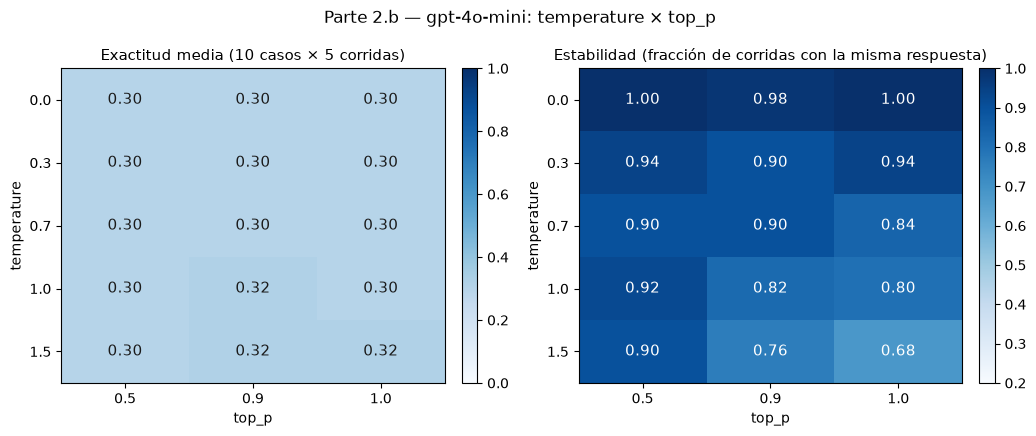

In [15]:
import matplotlib.pyplot as plt

tl.DIR_FIGURAS.mkdir(exist_ok=True)


def mapa(ax, col, titulo, vmin, vmax, fmt):
    M = cel.pivot(index="T", columns="top_p", values=col).reindex(index=TEMPS, columns=TOPPS)
    im = ax.imshow(M.values, cmap="Blues", vmin=vmin, vmax=vmax, aspect="auto")
    ax.set_xticks(range(len(TOPPS)))
    ax.set_xticklabels([str(p) for p in TOPPS])
    ax.set_yticks(range(len(TEMPS)))
    ax.set_yticklabels([str(t) for t in TEMPS])
    ax.set_xlabel("top_p")
    ax.set_ylabel("temperature")
    ax.set_title(titulo, fontsize=11)
    for i in range(len(TEMPS)):
        for j in range(len(TOPPS)):
            v = M.values[i, j]
            if not np.isnan(v):
                ax.text(j, i, fmt.format(v), ha="center", va="center", fontsize=11,
                        color="white" if (v - vmin) / (vmax - vmin) > 0.55 else "#1a1a1a")
    return im


fig, axs = plt.subplots(1, 2, figsize=(10.5, 4.4))
im1 = mapa(axs[0], "exactitud", "Exactitud media (10 casos × 5 corridas)", 0, 1, "{:.2f}")
im2 = mapa(axs[1], "estabilidad", "Estabilidad (fracción de corridas con la misma respuesta)", 0.2, 1, "{:.2f}")
fig.colorbar(im1, ax=axs[0], fraction=0.046, pad=0.04)
fig.colorbar(im2, ax=axs[1], fraction=0.046, pad=0.04)
fig.suptitle(f"Parte 2.b — {tl.fila_modelo(MID_2B)['modelo']}: temperature × top_p", fontsize=12)
fig.tight_layout()
fig.savefig(tl.DIR_FIGURAS / "p2b_mapas.png", dpi=150, bbox_inches="tight")
plt.show()

## 2.b.5 T = 0: ¿las corridas coinciden?
Con T = 0 el modelo debería tomar siempre el token más probable, y top_p no debería importar (el núcleo siempre contiene el argmax). Para cada caso miramos las 15 salidas con T = 0 (5 corridas × 3 valores de top_p) y contamos cuántas salidas **distintas** hubo. Si no es 1, la API no es reproducible bit a bit, y eso se reporta como hallazgo.

In [16]:
t0 = ok[ok["T"] == 0.0]
por_caso = t0.groupby("caso").txt.agg(salidas_distintas="nunique", detalle=lambda s: dict(collections.Counter(s).most_common()))
por_caso = por_caso.reindex([c["id"] for c in casos])
print(por_caso.to_string())
n_rep = int((por_caso.salidas_distintas == 1).sum())
print(f"\nCasos con T=0 idénticos en las {len(t0) // len(casos)} corridas: {n_rep} de {len(por_caso)}")

      salidas_distintas                      detalle
caso                                                
F1                    1                 {'8193': 15}
F2                    1                  {'311': 15}
M1                    1                  {'731': 15}
M2                    1                 {'2160': 15}
D1                    1                {'76526': 15}
D2                    1                {'63424': 15}
D3                    2  {'172048': 14, '172488': 1}
X1                    1               {'502752': 15}
X2                    1              {'3862035': 15}
P1                    1                  {'429': 15}

Casos con T=0 idénticos en las 15 corridas: 9 de 10


## 2.b.6 Barrido de top_k (local)
top_k ∈ {1, 5, 40} sobre qwen3:1.7b con **temperature = 1.0 y top_p = 1.0 fijados explícitamente** (la 2.a mostró que los valores por defecto de Ollama, 0.6 / 20 / 0.95, ya recortan la distribución), 5 corridas por caso. Además una referencia **greedy** (T = 0) con 5 corridas, para comprobar dos cosas: (1) que top_k = 1 da la misma salida en las 5 corridas y (2) que coincide con greedy.

In [17]:
PARTE_K = "2b_topk"
T_LOCAL = 1.0
KS = [1, 5, 40]
LOCAL_2B = {"think": False, "num_predict": 100, "top_p": 1.0}
tareas_k = []
for k in KS:
    for c in casos:
        for i in range(N2B):
            tareas_k.append(dict(modelo_id="open_weight_pequeno", prompt=prompts[c["id"]],
                                 params={**LOCAL_2B, "temperature": T_LOCAL, "top_k": k}, parte=PARTE_K,
                                 caso=c["id"], variante=f"top_k={k}", corrida=i, esperado=c["respuesta_esperada"]))
for c in casos:
    for i in range(N2B):
        tareas_k.append(dict(modelo_id="open_weight_pequeno", prompt=prompts[c["id"]],
                             params={**LOCAL_2B, "temperature": 0.0, "top_k": 100}, parte=PARTE_K,
                             caso=c["id"], variante="greedy(T=0)", corrida=i, esperado=c["respuesta_esperada"]))

if RELANZAR_2B:
    tl.reemplazar_partes({PARTE_K})
hay_k = any(f["parte"] == PARTE_K for f in tl.leer_filas())
if not hay_k:
    print(f"Llamadas locales: {len(tareas_k)} (costo 0 USD, una a una)")
    tl.correr_lote(tareas_k, hilos=1, mostrar=False)
else:
    print("Ya hay corridas de top_k: se reutilizan (RELANZAR_2B = True para repetirlas).")

k_rows = pd.DataFrame([f for f in tl.leer_filas() if f["parte"] == PARTE_K])
for c in ["tokens_salida", "acierto", "corrida", "latencia_s"]:
    k_rows[c] = pd.to_numeric(k_rows[c], errors="coerce")
kok = k_rows[k_rows.error == ""].drop_duplicates(subset=["variante", "caso", "corrida"], keep="last").copy()
kok["resp"] = kok.prediccion.map(lambda x: "∅" if x in ("", None) or (isinstance(x, float) and np.isnan(x)) else str(x))
kok["txt"] = kok.salida.str.strip()

filas_k = []
for v in [f"top_k={k}" for k in KS] + ["greedy(T=0)"]:
    g = kok[kok.variante == v]
    modal = g.groupby("caso").resp.agg(lambda s: s.value_counts().iloc[0])
    modal_txt = g.groupby("caso").txt.agg(lambda s: s.value_counts().iloc[0])
    filas_k.append({"variante": v, "llamadas_ok": len(g), "exactitud": round(g.acierto.mean(), 3),
                    "estabilidad_respuesta": round((modal / N2B).mean(), 3), "casos_5de5_respuesta": int((modal == N2B).sum()),
                    "casos_5de5_texto": int((modal_txt == N2B).sum()), "tokens_salida_medio": round(g.tokens_salida.mean(), 2)})
tabla_k = pd.DataFrame(filas_k)
tabla_k.to_csv(tl.DIR_RESULTADOS / "p2b_topk.csv", index=False)
print(tabla_k.to_string(index=False))

# ¿top_k = 1 reproduce greedy?
g1 = kok[kok.variante == "top_k=1"].groupby("caso").txt.agg(set)
gg = kok[kok.variante == "greedy(T=0)"].groupby("caso").txt.agg(set)
igual = [c["id"] for c in casos if c["id"] in g1.index and c["id"] in gg.index and len(g1[c["id"]]) == 1 and g1[c["id"]] == gg[c["id"]]]
print(f"\ntop_k=1: mismas 5 salidas entre sí en {int((g1.map(len) == 1).sum())}/{len(g1)} casos | idéntica a greedy (T=0) en {len(igual)}/{len(g1)} casos")
dif = [c["id"] for c in casos if c["id"] in g1.index and c["id"] not in igual]
print("Casos donde top_k=1 NO reproduce greedy:", dif if dif else "ninguno")

Ya hay corridas de top_k: se reutilizan (RELANZAR_2B = True para repetirlas).
   variante  llamadas_ok  exactitud  estabilidad_respuesta  casos_5de5_respuesta  casos_5de5_texto  tokens_salida_medio
    top_k=1           50       0.40                   1.00                    10                10                21.70
    top_k=5           50       0.42                   0.72                     5                 1                26.76
   top_k=40           50       0.48                   0.68                     4                 1                28.48
greedy(T=0)           50       0.40                   1.00                    10                10                21.70

top_k=1: mismas 5 salidas entre sí en 10/10 casos | idéntica a greedy (T=0) en 10/10 casos
Casos donde top_k=1 NO reproduce greedy: ninguno


## 2.b.7 Estimado contra medido

In [18]:
real_2b = ok.costo_usd.sum()
print(f"Costo estimado: {est_2b:.4f} USD | costo real de la API: {real_2b:.6f} USD | el supuesto del taller (1000/600 tokens por llamada) daba {est_taller:.3f} USD")
print(f"Tokens medios por llamada — entrada: supuesto {tin:.1f}, medido {ok.tokens_entrada.mean():.1f} | salida: supuesto {tout:.1f}, medido {ok.tokens_salida.mean():.2f}")
print(f"Latencia mediana por llamada (en paralelo, no comparable con la Parte 1): {ok.latencia_s.median():.3f} s")

Costo estimado: 0.0060 USD | costo real de la API: 0.006141 USD | el supuesto del taller (1000/600 tokens por llamada) daba 0.383 USD
Tokens medios por llamada — entrada: supuesto 41.7, medido 41.7 | salida: supuesto 2.8, medido 3.22
Latencia mediana por llamada (en paralelo, no comparable con la Parte 1): 0.815 s
